<a href="https://colab.research.google.com/github/Hafizusmanjaved/Final-year-project-Usman1/blob/main/Heart_HyperTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated Diagnosis of Coronary Heart Disease Using Machine Learning Classification**

# **Part 1: Importing Files and Loading Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import recall_score, classification_report, accuracy_score

# URLs for all four datasets
data_urls = {
    "Cleveland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "Hungary": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "Switzerland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    "Long Beach VA": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data"
}

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

# Load and combine
df_list = []
for region, url in data_urls.items():
    temp_df = pd.read_csv(url, names=columns, na_values='?')
    temp_df['region'] = region  # Track origin for EDA
    df_list.append(temp_df)

df_combined = pd.concat(df_list, ignore_index=True)
print(f"Combined Dataset: {df_combined.shape[0]} rows from 4 regions.")

Combined Dataset: 920 rows from 4 regions.


# **Part II: Exploratory Data Analysis**

## **Checking Missing Values**

Missing values per feature:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
region        0
dtype: int64


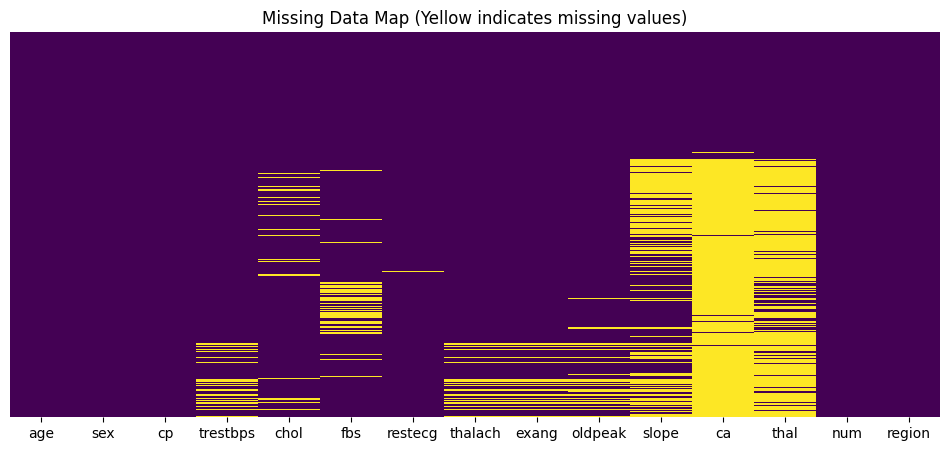

In [2]:
# Convert '?' to NaN so Pandas can recognize them as missing
df_combined = df_combined.replace('?', np.nan)

# Check the count of missing values per column
print("Missing values per feature:")
print(df_combined.isnull().sum())

# Visualize the 'sparsity' of the data
plt.figure(figsize=(12, 5))
sns.heatmap(df_combined.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Map (Yellow indicates missing values)")
plt.show()

## **Filling Missing Values using Interpolation**

In [3]:
import pandas as pd
import numpy as np

# 1. Convert '?' to NaN and ensure all features are numeric
# We exclude 'region' if you added it earlier, as it is a string
cols_to_convert = [c for c in df_combined.columns if c != 'region']
df_combined[cols_to_convert] = df_combined[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# 2. Define column types for specific imputation strategies
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# 3. Perform Imputation
# Fill categorical columns with the Mode (most frequent value)
for col in categorical_cols:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].fillna(df_combined[col].mode()[0])

# Fill continuous columns with the Median (robust to outliers)
for col in continuous_cols:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# 4. Final Re-check
print("--- Missing Values After Imputation ---")
missing_counts = df_combined.isnull().sum()
print(missing_counts)

if missing_counts.sum() == 0:
    print("\nSuccess: No missing values remaining.")
else:
    print(f"\nWarning: {missing_counts.sum()} missing values still present.")

--- Missing Values After Imputation ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
region      0
dtype: int64

Success: No missing values remaining.


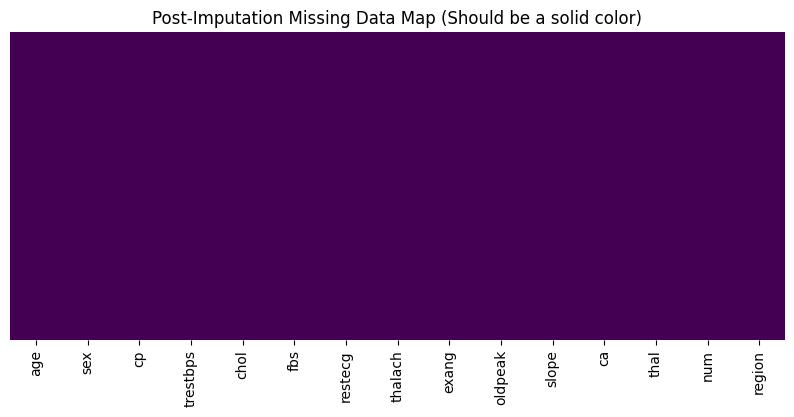

In [4]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_combined.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Post-Imputation Missing Data Map (Should be a solid color)")
plt.show()

## **Coorelation Heatmap**

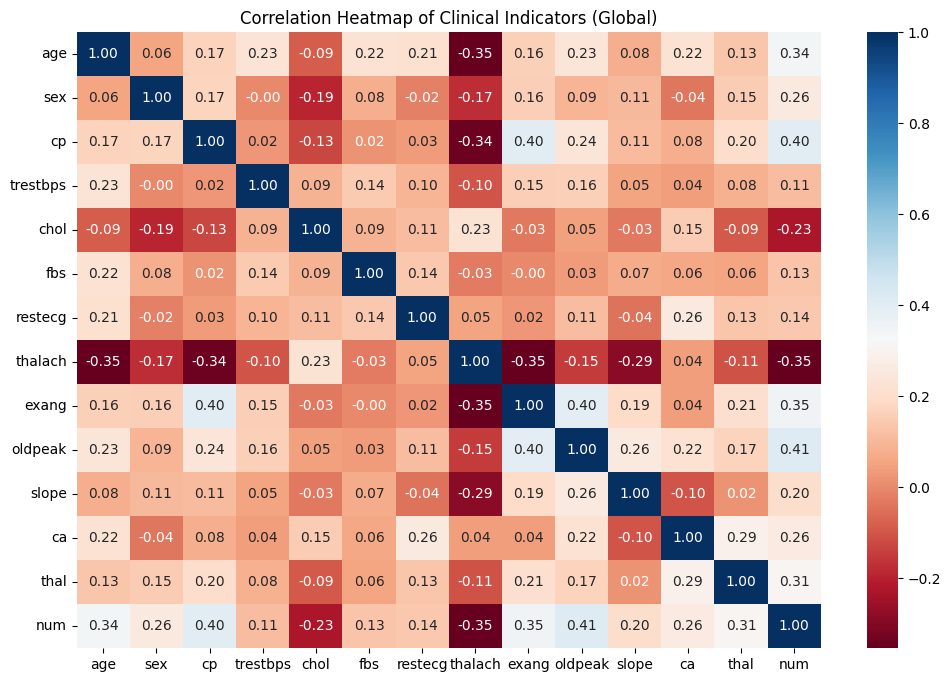

In [5]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_combined.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt='.2f')
plt.title("Correlation Heatmap of Clinical Indicators (Global)")
plt.show()

## **Distribution Graph**

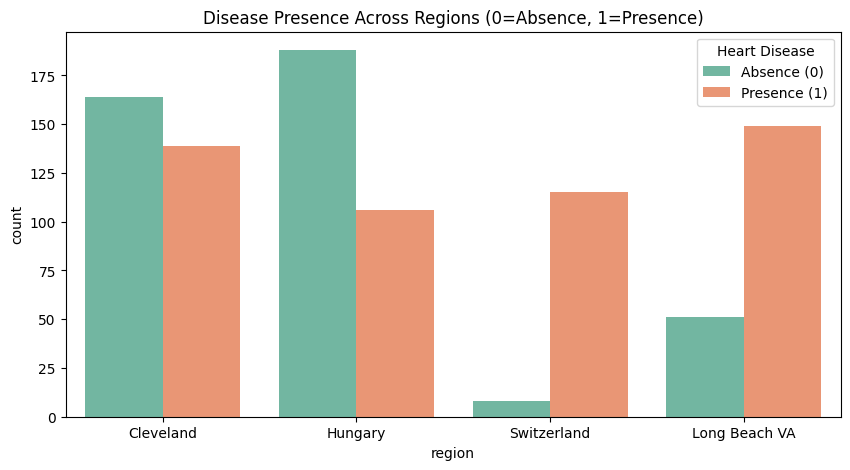

In [6]:
#Visualize Heart Disease Presence by Region
# We use 'num' > 0 to define disease presence
df_combined['has_disease'] = (df_combined['num'] > 0).astype(int)

plt.figure(figsize=(10, 5))
sns.countplot(data=df_combined, x='region', hue='has_disease', palette='Set2')
plt.title("Disease Presence Across Regions (0=Absence, 1=Presence)")
plt.legend(title='Heart Disease', labels=['Absence (0)', 'Presence (1)'])
plt.show()

/tmp/ipykernel_5966/3729379011.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='num', data=df_combined, palette='magma')


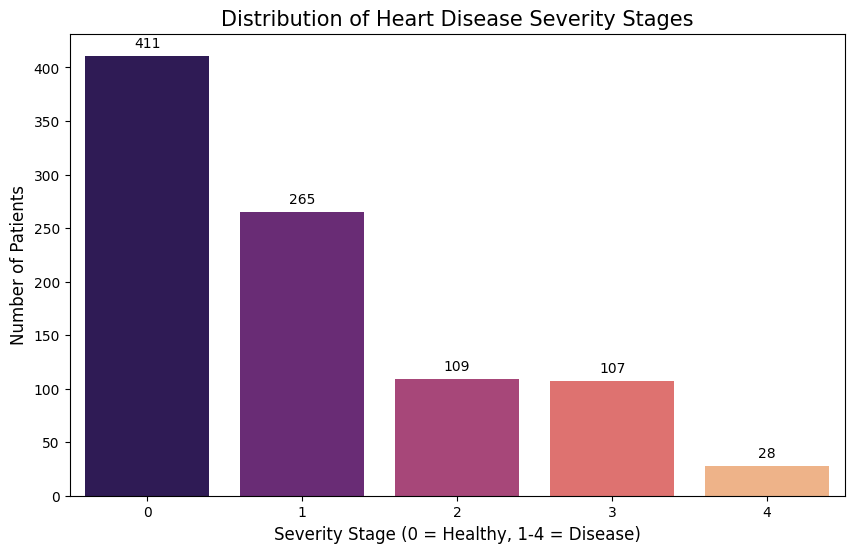

In [7]:
plt.figure(figsize=(10, 6))
# Create the countplot for the 5 stages
ax = sns.countplot(x='num', data=df_combined, palette='magma')

# Add labels and title
plt.title('Distribution of Heart Disease Severity Stages', fontsize=15)
plt.xlabel('Severity Stage (0 = Healthy, 1-4 = Disease)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()

In [8]:
df_combined.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,region,has_disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,0


# **Preprocessing Data**

In [9]:
import pandas as pd

# Define the columns that need encoding
# Note: sex, fbs, and exang are already binary (0/1),
# so they are typically left as-is, but can be added here if preferred.
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal', 'region']

# Apply One-Hot Encoding
# drop_first=True is used to avoid multicollinearity (the dummy variable trap)
# by removing one redundant column for each category.
df_encoded = pd.get_dummies(df_combined, columns=categorical_cols, drop_first=False)

# Verify the changes
print(f"Original shape: {df_combined.shape}")
print(f"Encoded shape: {df_encoded.shape}")
print(df_encoded.head())

Original shape: (920, 16)
Encoded shape: (920, 31)
    age  sex  trestbps   chol  fbs  thalach  exang  oldpeak  num  has_disease  \
0  63.0  1.0     145.0  233.0  1.0    150.0    0.0      2.3    0            0   
1  67.0  1.0     160.0  286.0  0.0    108.0    1.0      1.5    2            1   
2  67.0  1.0     120.0  229.0  0.0    129.0    1.0      2.6    1            1   
3  37.0  1.0     130.0  250.0  0.0    187.0    0.0      3.5    0            0   
4  41.0  0.0     130.0  204.0  0.0    172.0    0.0      1.4    0            0   

   ...  ca_1.0  ca_2.0  ca_3.0  thal_3.0  thal_6.0  thal_7.0  \
0  ...   False   False   False     False      True     False   
1  ...   False   False    True      True     False     False   
2  ...   False    True   False     False     False      True   
3  ...   False   False   False      True     False     False   
4  ...   False   False   False      True     False     False   

   region_Cleveland  region_Hungary  region_Long Beach VA  region_Switzerland

## **Splitting Train and Test Data**

In [10]:
from sklearn.model_selection import train_test_split

# 1. Separate features and target
# We drop 'num' because it is the target.
# We also drop 'has_disease' to prevent data leakage.
X = df_encoded.drop(columns=['num', 'has_disease'])
y = df_encoded['num']

# 2. Split the data
# test_size=0.2 means 20% of the data goes to the test set
# random_state ensures reproducibility
# stratify=y ensures the distribution of disease stages is similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verify the results
print(f"Total samples: {len(df_encoded)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Total samples: 920
Training samples: 736
Testing samples: 184
Number of features: 29


# **Model Training and Evaluation for Multi-Class**


Logistic Regression Results
Accuracy: 0.5652
              precision    recall  f1-score   support

           0       0.88      0.74      0.81        82
           1       0.62      0.47      0.54        53
           2       0.30      0.36      0.33        22
           3       0.17      0.24      0.20        21
           4       0.28      0.83      0.42         6

    accuracy                           0.57       184
   macro avg       0.45      0.53      0.46       184
weighted avg       0.64      0.57      0.59       184



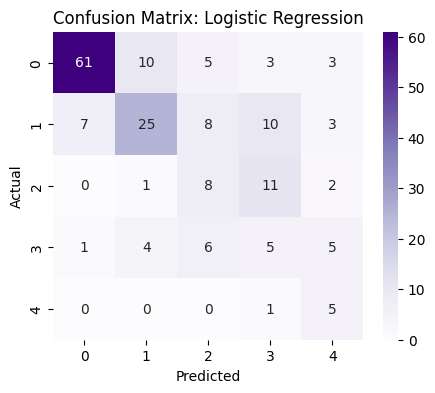


Random Forest Results
Accuracy: 0.5870
              precision    recall  f1-score   support

           0       0.75      0.89      0.82        82
           1       0.57      0.49      0.53        53
           2       0.07      0.05      0.05        22
           3       0.28      0.33      0.30        21
           4       1.00      0.17      0.29         6

    accuracy                           0.59       184
   macro avg       0.53      0.39      0.40       184
weighted avg       0.57      0.59      0.57       184



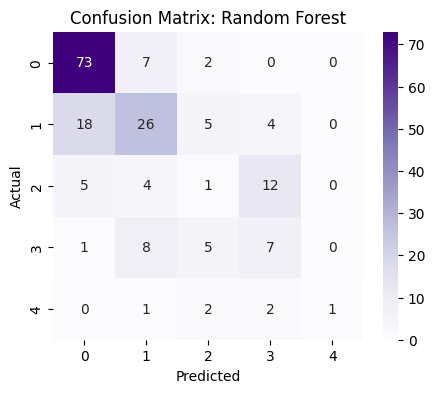


SVM Results
Accuracy: 0.5326
              precision    recall  f1-score   support

           0       0.87      0.74      0.80        82
           1       0.54      0.49      0.51        53
           2       0.16      0.23      0.19        22
           3       0.20      0.24      0.22        21
           4       0.10      0.17      0.12         6

    accuracy                           0.53       184
   macro avg       0.37      0.37      0.37       184
weighted avg       0.59      0.53      0.56       184



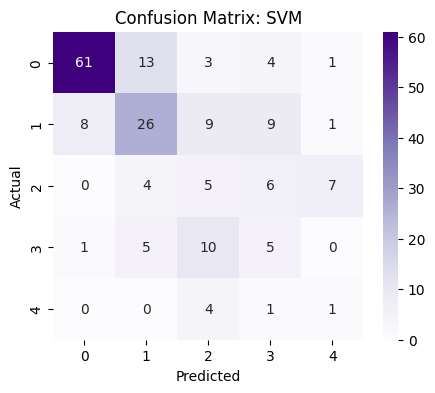


--- Model Accuracy Ranking ---
                 Model  Accuracy
1        Random Forest  0.586957
0  Logistic Regression  0.565217
2                  SVM  0.532609


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Scale the features (Essential for SVM, KNN, and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "SVM": SVC(probability=True, kernel='rbf', class_weight='balanced'),
}

# 3. Train and Evaluate
results = {}

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{'='*30}\n{name} Results\n{'='*30}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 4. Final Comparison Table
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\n--- Model Accuracy Ranking ---")
print(comparison_df)

## **Model Training and Evaluation after balancing the data**

In [12]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Check original class distribution
print(f"Original class distribution: {Counter(y_train)}")

# 2. Apply SMOTE to balance the training set
# This will ensure all classes (0-4) have the same number of samples
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced class distribution: {Counter(y_train_balanced)}")

# 3. Re-run the models on the balanced data
balanced_results = {}

for name, model in models.items():
    # Fit on the BALANCED training data
    model.fit(X_train_balanced, y_train_balanced)

    # Predict on the (unbalanced) test data to see real-world performance
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    balanced_results[name] = acc

    print(f"\n{'='*30}\n{name} (Balanced) Results\n{'='*30}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# 4. Compare ranking
comparison_df = pd.DataFrame(list(balanced_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\n--- Balanced Model Accuracy Ranking ---")
print(comparison_df)

Original class distribution: Counter({0: 329, 1: 212, 2: 87, 3: 86, 4: 22})
Balanced class distribution: Counter({3: 329, 0: 329, 2: 329, 1: 329, 4: 329})

Logistic Regression (Balanced) Results
Accuracy: 0.5217
              precision    recall  f1-score   support

           0       0.88      0.72      0.79        82
           1       0.53      0.47      0.50        53
           2       0.16      0.18      0.17        22
           3       0.14      0.19      0.16        21
           4       0.24      0.67      0.35         6

    accuracy                           0.52       184
   macro avg       0.39      0.45      0.39       184
weighted avg       0.59      0.52      0.55       184


Random Forest (Balanced) Results
Accuracy: 0.6141
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.59      0.62      0.61        53
           2       0.17      0.18      0.17        22
           3       0.28      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



SVM (Balanced) Results
Accuracy: 0.5598
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.52      0.51      0.51        53
           2       0.20      0.23      0.21        22
           3       0.15      0.19      0.17        21
           4       0.33      0.17      0.22         6

    accuracy                           0.56       184
   macro avg       0.41      0.38      0.39       184
weighted avg       0.58      0.56      0.57       184


--- Balanced Model Accuracy Ranking ---
                 Model  Accuracy
1        Random Forest  0.614130
2                  SVM  0.559783
0  Logistic Regression  0.521739


## **Hyperparameter optimization using Random Search for Multi-Class**

In [13]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import pandas as pd

# 1. Check original class distribution
print(f"Original class distribution: {Counter(y_train)}")

# 2. Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced class distribution: {Counter(y_train_balanced)}")

# Define parameter grids for Grid Search
param_grids = {
    "Logistic Regression": {'C': [0.1, 1, 10]},
    "Random Forest": {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]},
    "SVM": {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},

}

# 3. Re-run the models on the balanced data with Grid Search
balanced_results = []

for name, model in models.items():
    print(f"\nStarting Grid Search for {name}...")

    # Initialize GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grids.get(name, {}),
                               cv=3, scoring='accuracy', n_jobs=-1)

    # Fit on the BALANCED training data
    grid_search.fit(X_train_balanced, y_train_balanced)

    # Use the best model found by Grid Search
    best_model = grid_search.best_estimator_

    # Predict on the (unbalanced) test data
    y_pred = best_model.predict(X_test_scaled)

    # Store detailed metrics
    metrics = {
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    }
    balanced_results.append(metrics)

    print(f"{'='*30}\n{name} (Optimized) Results\n{'='*30}")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(classification_report(y_test, y_pred))

# 4. Compare ranking
comparison_df = pd.DataFrame(balanced_results).sort_values(by='Accuracy', ascending=False)
print("\n--- Optimized Balanced Model Ranking ---")
print(comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']])

Original class distribution: Counter({0: 329, 1: 212, 2: 87, 3: 86, 4: 22})
Balanced class distribution: Counter({3: 329, 0: 329, 2: 329, 1: 329, 4: 329})

Starting Grid Search for Logistic Regression...
Logistic Regression (Optimized) Results
Best Parameters: {'C': 0.1}
Accuracy: 0.5380
              precision    recall  f1-score   support

           0       0.87      0.73      0.79        82
           1       0.59      0.45      0.51        53
           2       0.19      0.23      0.21        22
           3       0.19      0.29      0.23        21
           4       0.24      0.67      0.35         6

    accuracy                           0.54       184
   macro avg       0.42      0.47      0.42       184
weighted avg       0.61      0.54      0.56       184


Starting Grid Search for Random Forest...
Random Forest (Optimized) Results
Best Parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.5870
              precision    recall  f1-score   support

           0   

# **Model Training and Evaluation for Binary Class**

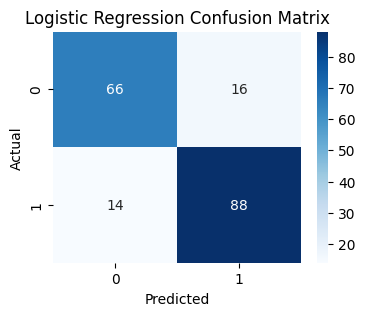

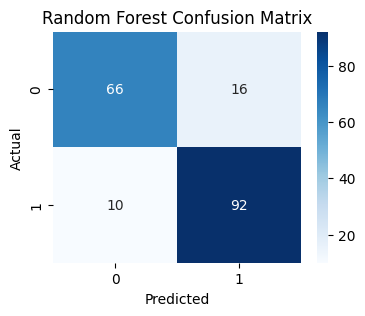

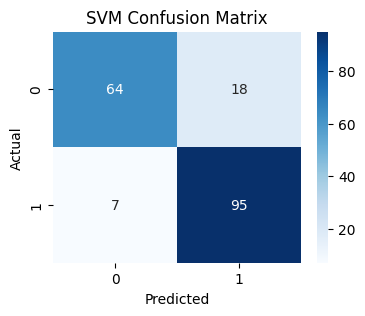


--- Final Performance Comparison (Binary Classification) ---
              Model  Accuracy  Precision   Recall  F1-Score      AUC
                SVM  0.864130   0.840708 0.931373  0.883721 0.922286
      Random Forest  0.858696   0.851852 0.901961  0.876190 0.928802
Logistic Regression  0.836957   0.846154 0.862745  0.854369 0.922166


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Binary Conversion
y_binary = (df_encoded['num'] > 0).astype(int)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 3. Scaling & Balancing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 4. Define All Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf'),
}

# 5. Loop for Training and Evaluation
performance_metrics = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    performance_metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC": auc
    })

    # Quick Confusion Matrix Plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 6. Final Comparison Table
df_results = pd.DataFrame(performance_metrics).sort_values(by="Accuracy", ascending=False)
print("\n--- Final Performance Comparison (Binary Classification) ---")
print(df_results.to_string(index=False))

## **Hyperparameter optimization using Random Search for Binary-Class**

Running Grid Search for Logistic Regression...


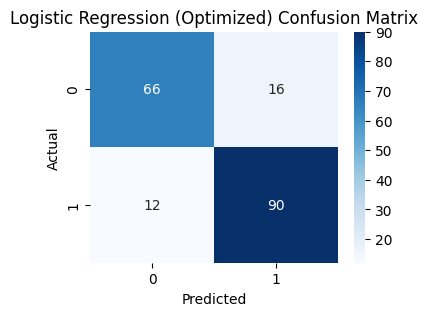

Running Grid Search for Random Forest...


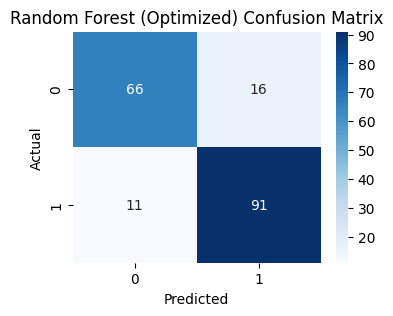

Running Grid Search for SVM...


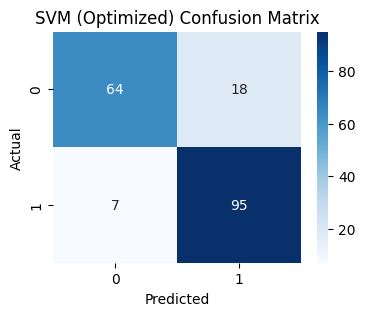


--- Final Performance Comparison (Optimized Binary Classification) ---
              Model                            Best Params  Accuracy  Precision   Recall  F1-Score      AUC
                SVM             {'C': 1, 'gamma': 'scale'}  0.864130   0.840708 0.931373  0.883721 0.922286
      Random Forest {'max_depth': 10, 'n_estimators': 100}  0.853261   0.850467 0.892157  0.870813 0.933166
Logistic Regression                             {'C': 0.1}  0.847826   0.849057 0.882353  0.865385 0.923242


In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Binary Conversion
y_binary = (df_encoded['num'] > 0).astype(int)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 3. Scaling & Balancing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 4. Define All Models and their Parameter Grids
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, kernel='rbf'),
}

param_grids = {
    "Logistic Regression": {'C': [0.1, 1, 10]},
    "Random Forest": {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]},
    "SVM": {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
}

# 5. Loop for Training (with Grid Search) and Evaluation
performance_metrics = []

for name, model in models.items():
    print(f"Running Grid Search for {name}...")

    # Initialize Grid Search
    grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=3, scoring='accuracy', n_jobs=-1)

    # Fit on balanced data
    grid_search.fit(X_train_bal, y_train_bal)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Predict
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    performance_metrics.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC": auc
    })

    # Quick Confusion Matrix Plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} (Optimized) Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 6. Final Comparison Table
df_results = pd.DataFrame(performance_metrics).sort_values(by="Accuracy", ascending=False)
print("\n--- Final Performance Comparison (Optimized Binary Classification) ---")
print(df_results.to_string(index=False))

# **K-Fold Cross Validation**

In [16]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# 1. Initialize K-Fold strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Storage for final results
cv_performance = []

# Loop through each model
for name, model in models.items():
    print(f"Manually running 5-Fold CV for {name}...")

    # Lists to store scores for each fold
    fold_accuracies = []
    fold_recalls = []
    fold_aucs = []

    # 3. Manual Fold Loop
    for train_index, test_index in skf.split(X, y_binary):
        # Split into training and testing for this fold
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y_binary.iloc[train_index], y_binary.iloc[test_index]

        # 4. Scaling (applied fold-by-fold)
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_test_fold_scaled = scaler.transform(X_test_fold)

        # 5. Balancing (applied only to the training fold)
        smote = SMOTE(random_state=42)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_fold_scaled, y_train_fold)

        # 6. Fit and Predict
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_fold_scaled)
        y_prob = model.predict_proba(X_test_fold_scaled)[:, 1]

        # Store metrics for this fold
        fold_accuracies.append(accuracy_score(y_test_fold, y_pred))
        fold_recalls.append(recall_score(y_test_fold, y_pred))
        fold_aucs.append(roc_auc_score(y_test_fold, y_prob))

    # 7. Calculate average performance for the model
    cv_performance.append({
        "Model": name,
        "CV Accuracy": np.mean(fold_accuracies),
        "CV Recall": np.mean(fold_recalls),
        "CV AUC": np.mean(fold_aucs),
        "Accuracy Std": np.std(fold_accuracies)
    })

# 8. Final Comparison Table
df_cv_manual = pd.DataFrame(cv_performance).sort_values(by="CV Accuracy", ascending=False)
print("\n--- Manual K-Fold CV Results (Binary) ---")
print(df_cv_manual.to_string(index=False))

Manually running 5-Fold CV for Logistic Regression...
Manually running 5-Fold CV for Random Forest...
Manually running 5-Fold CV for SVM...

--- Manual K-Fold CV Results (Binary) ---
              Model  CV Accuracy  CV Recall   CV AUC  Accuracy Std
Logistic Regression     0.822826   0.823316 0.905942      0.031802
                SVM     0.819565   0.846845 0.900145      0.022382
      Random Forest     0.818478   0.846806 0.889820      0.014420


# **Feature Importance using best Model**

Calculating permutation importance (this may take a moment)...


/tmp/ipykernel_5966/3787089529.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


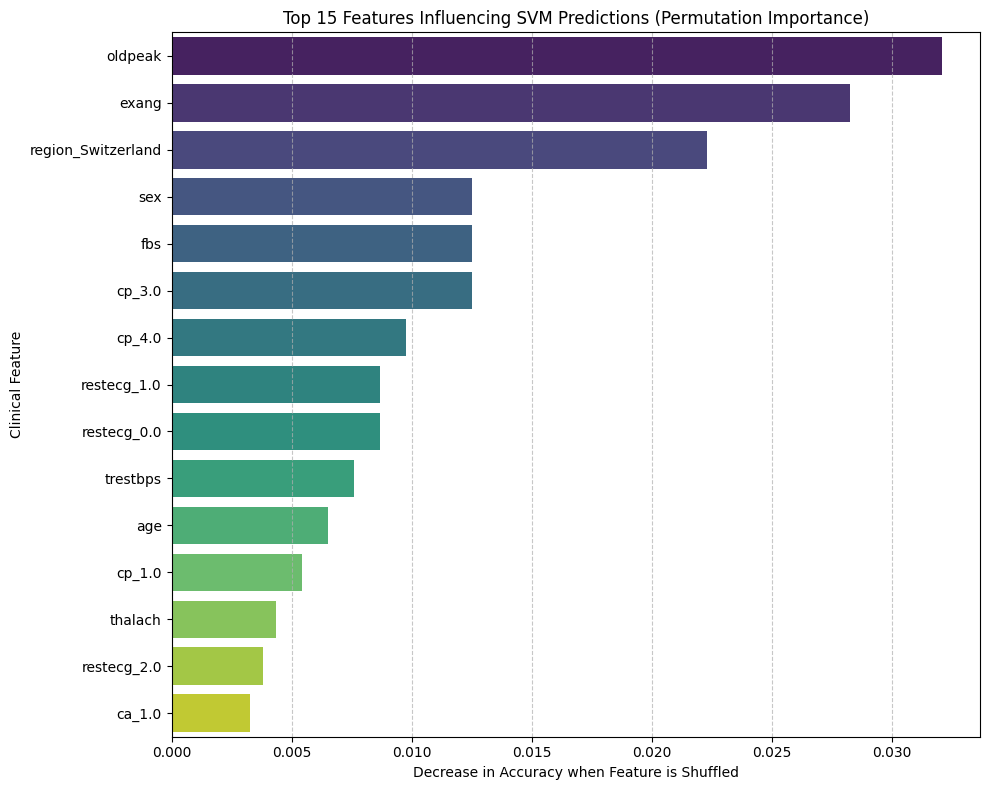


--- SVM Feature Ranking ---
           Feature  Importance  Std_Dev
           oldpeak    0.032065 0.007857
             exang    0.028261 0.008349
region_Switzerland    0.022283 0.011770
               sex    0.012500 0.008079
               fbs    0.012500 0.007312
            cp_3.0    0.012500 0.004891
            cp_4.0    0.009783 0.009029
       restecg_1.0    0.008696 0.006052
       restecg_0.0    0.008696 0.006052
          trestbps    0.007609 0.006960


In [17]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the SVM model (using the balanced data from your previous steps)
# Ensure probability=True so we can use AUC if needed
svm_model = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
svm_model.fit(X_train_bal, y_train_bal)

# 2. Calculate Permutation Importance
# This shuffles each feature 10 times to see how much Accuracy drops
print("Calculating permutation importance (this may take a moment)...")
perm_importance = permutation_importance(
    svm_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 3. Organize the results into a DataFrame
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std_Dev': perm_importance.importances_std
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the Results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Features Influencing SVM Predictions (Permutation Importance)')
plt.xlabel('Decrease in Accuracy when Feature is Shuffled')
plt.ylabel('Clinical Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Print the sorted list
print("\n--- SVM Feature Ranking ---")
print(importance_df.head(10).to_string(index=False))